# VortexTech AI & ML Internship — Week 2
## Machine Learning Classification Model

### Project Objective

This project builds a binary classification model using the Titanic(train) dataset to predict whether a passenger survived. The dataset is cleaned and preprocessed, categorical features are converted into numerical values, and the data is split into training and testing sets. Two classification algorithms, Logistic Regression and Decision Tree, are trained and evaluated using accuracy, precision, recall, and F1-score.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
# Load Titanic(training) Datase
import pandas as pd
df = pd.read_csv("data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
# Check dataset shape
print("Dataset Shape:", df.shape)
# Check column information
df.info()
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin       

## Exploratory Data Analysis

The following chart shows the distribution of passengers who survived and did not survive. This helps us understand the target variable before training the classification models.

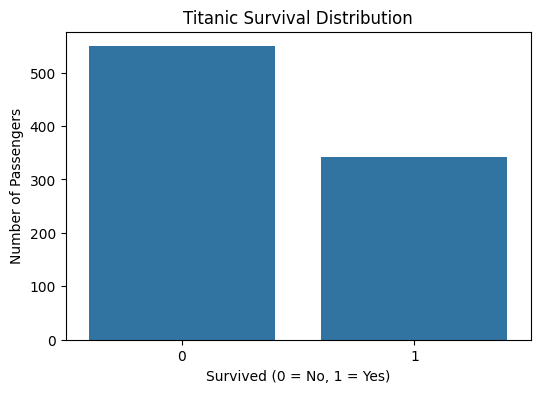

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

In [15]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [0.810056, 0.782123],
    "Precision": [0.785714, 0.727273],
    "Recall": [0.743243, 0.756757],
    "F1-Score": [0.763889, 0.741722]    })
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Decision Tree,0.782123,0.727273,0.756757,0.741722


In [16]:
# Data Cleaning
# Drop columns that are not useful for model
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())
# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [17]:
# Convert categorical columns into numerical
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)
# Check updated dataset
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [18]:
# Separate Features (X) and Target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print("Survived")
print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Target:
Survived

Feature shape: (891, 8)
Target shape: (891,)


In [19]:
from sklearn.model_selection import train_test_split
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42 )
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [20]:
from sklearn.linear_model import LogisticRegression
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)
# Train the model
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Make predictions on test data
predictions = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print("--------------------------------")
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

--------------------------------
Logistic Regression Performance
--------------------------------
Accuracy : 0.8101
Precision: 0.7857
Recall   : 0.7432
F1-Score : 0.7639


In [22]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
# Train the model
tree_model.fit(X_train, y_train)
# Make predictions
tree_predictions = tree_model.predict(X_test)
# Calculate evaluation metrics
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)
print("-------------------------")
print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1-Score : {tree_f1:.4f}")

-------------------------
Decision Tree Performance
-------------------------
Accuracy : 0.7821
Precision: 0.7273
Recall   : 0.7568
F1-Score : 0.7417


In [23]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, tree_accuracy],
    "Precision": [precision, tree_precision],
    "Recall": [recall, tree_recall],
    "F1-Score": [f1, tree_f1] })
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Decision Tree,0.782123,0.727273,0.756757,0.741722


## Final Results and Interpretation

Two classification models were trained and evaluated: Logistic Regression and Decision Tree. Logistic Regression achieved the best overall performance with an accuracy of 81.01% and an F1-score of 76.39%, compared with 78.21% accuracy and 74.17% F1-score for the Decision Tree. Although the Decision Tree achieved slightly higher recall, Logistic Regression provided better overall results across most evaluation metrics. One possible improvement would be to perform hyperparameter tuning and feature engineering to improve model performance.